In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm


In [2]:
df = pd.read_csv("loan.csv")
df.head()
print(df.shape)

(614, 10)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
dtypes: float64(3), int64(1), str(6)
memory usage: 64.5 KB


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
dtype: int64

In [6]:
df['loan_Amount_log'] = np.log(df['LoanAmount'])

<Axes: >

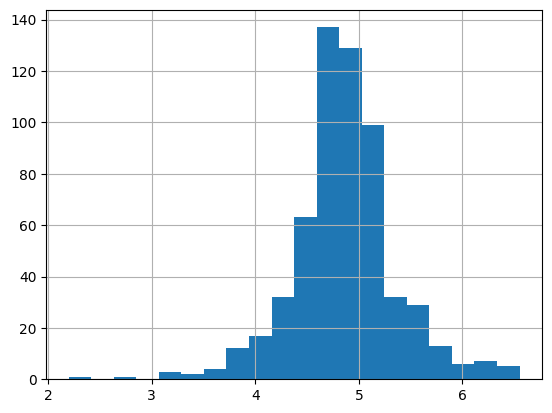

In [7]:
df['loan_Amount_log'].hist(bins = 20)

In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
loan_Amount_log      22
dtype: int64

In [9]:
df['TotalIncome'] = df['ApplicantIncome']+ df['CoapplicantIncome']

In [10]:
df['TotalIncome_log'] = np.log(df['TotalIncome'])

<Axes: >

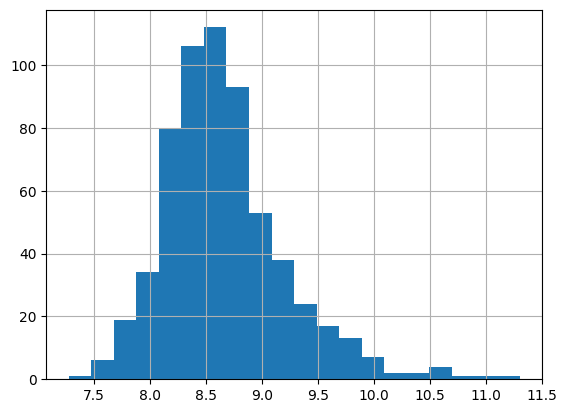

In [11]:
df['TotalIncome_log'].hist(bins = 20)

In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
loan_Amount_log      22
TotalIncome           0
TotalIncome_log       0
dtype: int64

In [13]:
df['Gender'].fillna(df['Gender'].mode()[0] , inplace  = True)
df['Dependents'].fillna(df['Dependents'].mode()[0] , inplace  = True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0] , inplace  = True)
df['Married'].fillna(df['Married'].mode()[0] , inplace = True)





C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\2183557166.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0] , inplace  = True)
C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\2183557166.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

0       No
1      Yes
2      Yes
3      Yes
4       No
      ... 
609     No
610    Yes
611    Yes
612    Yes
613     No
Name: Married, Length: 614, dtype: str

In [14]:
df.LoanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())

<Axes: >

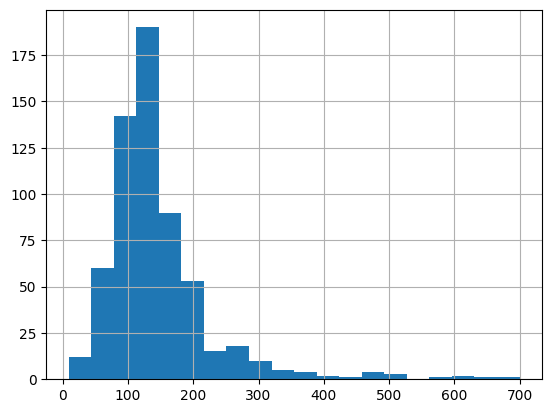

In [15]:
df['LoanAmount'].hist(bins = 20)

In [16]:
df.loan_Amount_log = df.loan_Amount_log.fillna(df.loan_Amount_log.mean())

<Axes: >

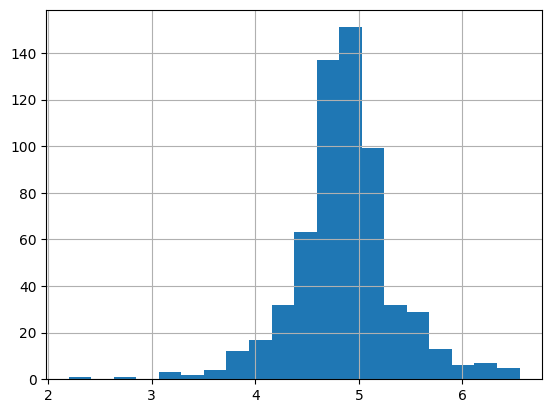

In [17]:
df['loan_Amount_log'].hist(bins = 20)

In [18]:
df.fillna({'Loan_Amount_Term': df['Loan_Amount_Term'].mode()[0]}, inplace=True)
df.fillna({'Gender': df['Gender'].mode()[0]}, inplace=True)
df.fillna({'Married': df['Married'].mode()[0]}, inplace=True)
df.fillna({'Dependents': df['Dependents'].mode()[0]}, inplace=True)
df.fillna({'Self_Employed' : df['Self_Employed'].mode()[0]} , inplace = True)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,loan_Amount_log,TotalIncome,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,4.857444,5849.0,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,4.852030,6091.0,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,4.189655,3000.0,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,4.787492,4941.0,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,4.948760,6000.0,8.699515
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,4.262680,2900.0,7.972466
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.000000,180.0,3.688879,4106.0,8.320205
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,5.533389,8312.0,9.025456
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,5.231109,7583.0,8.933664


In [19]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
loan_Amount_log      0
TotalIncome          0
TotalIncome_log      0
dtype: int64

In [42]:
x = df.iloc[: , np.r_[1:5  , 9:11 , 13:-1]].values
y = df.iloc[: , 2].values

In [21]:
x

array([['Male', 'No', '0', 'Graduate', 360.0, 4.857444178729352],
       ['Male', 'Yes', '1', 'Graduate', 360.0, 4.852030263919617],
       ['Male', 'Yes', '0', 'Graduate', 360.0, 4.189654742026425],
       ...,
       ['Male', 'Yes', '1', 'Graduate', 360.0, 5.53338948872752],
       ['Male', 'Yes', '2', 'Graduate', 360.0, 5.231108616854587],
       ['Female', 'No', '0', 'Graduate', 360.0, 4.890349128221754]],
      shape=(614, 6), dtype=object)

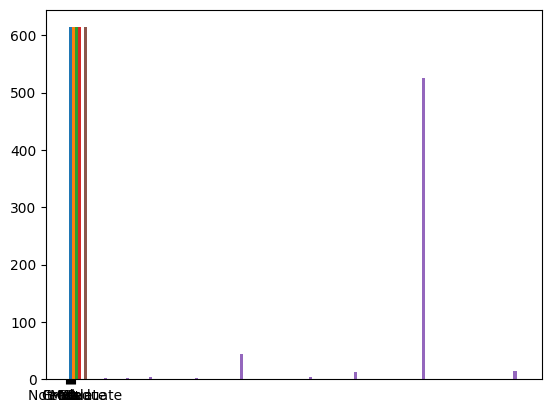

In [38]:
plt.hist(x , bins = 20)
plt.show()

In [43]:
y

<ArrowStringArray>
[ 'No', 'Yes', 'Yes', 'Yes',  'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
 ...
 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',  'No', 'Yes', 'Yes', 'Yes',  'No']
Length: 614, dtype: str

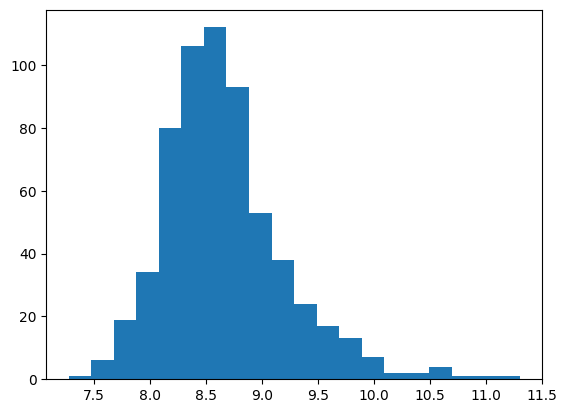

In [24]:
plt.hist(y , bins =20)
plt.show()

In [25]:
print(f"percentage of missing gender is {(df['Gender'].isnull().sum() / df.shape[0])* 100}%")

percentage of missing gender is 0.0%


In [26]:
print('number of peoples who take lone as group by gender :')
print(df['Gender'].value_counts())

number of peoples who take lone as group by gender :
Gender
Male      502
Female    112
Name: count, dtype: int64


C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\833002186.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Gender' , data = df , palette = 'Set2')


<Axes: xlabel='Gender', ylabel='count'>

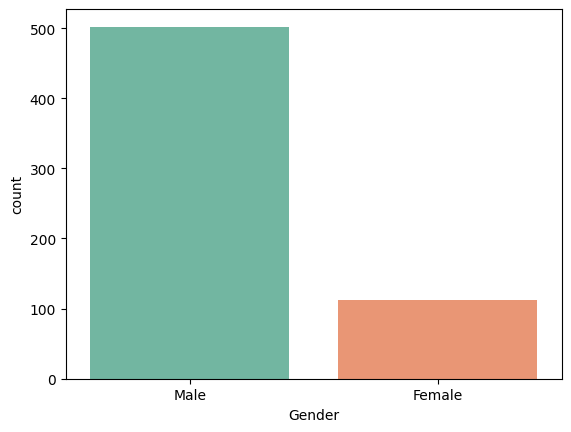

In [27]:
sns.countplot(x = 'Gender' , data = df , palette = 'Set2')

The number of peoples take loan as group by Martial status
Married
Yes    401
No     213
Name: count, dtype: int64


C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\1986328073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Married' , data = df , palette = 'Set2')


<Axes: xlabel='Married', ylabel='count'>

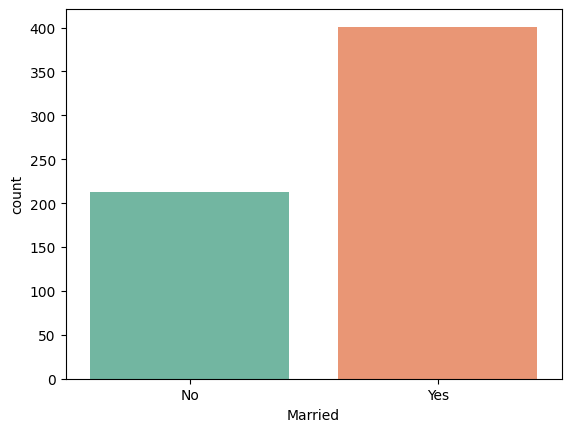

In [28]:
print("The number of peoples take loan as group by Martial status")
print(df['Married'].value_counts())
sns.countplot(x = 'Married' , data = df , palette = 'Set2')

number of people who loan as group by dependents
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64


C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\571079854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Dependents' , data = df , palette  = 'Set2')


<Axes: xlabel='Dependents', ylabel='count'>

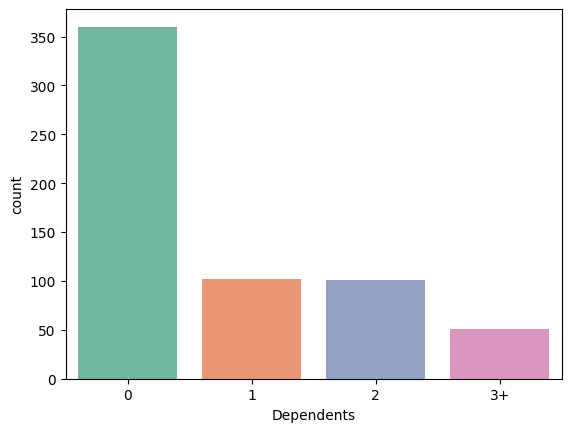

In [29]:
print("number of people who loan as group by dependents")
print(df['Dependents'].value_counts())
sns.countplot(x = 'Dependents' , data = df , palette  = 'Set2')

Number of peoples take loan as group by self_employes
Self_Employed
No     532
Yes     82
Name: count, dtype: int64


C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\1207599445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Self_Employed' , data  = df  , palette = 'Set2')


<Axes: xlabel='Self_Employed', ylabel='count'>

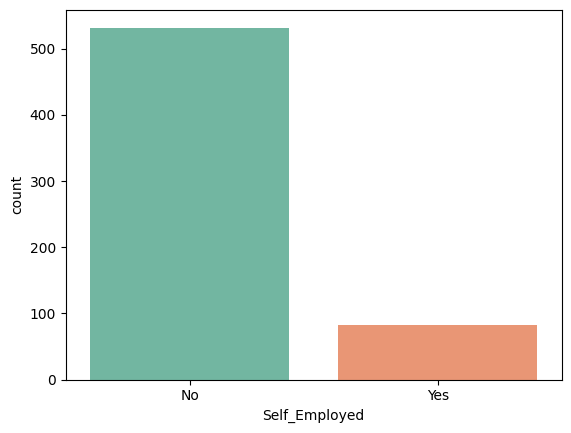

In [30]:
print('Number of peoples take loan as group by self_employes')
print(df['Self_Employed'].value_counts())
sns.countplot(x = 'Self_Employed' , data  = df  , palette = 'Set2')

C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\1986328073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Married' , data = df , palette = 'Set2')


The number of peoples take loan as group by Martial status
Married
Yes    401
No     213
Name: count, dtype: int64


<Axes: xlabel='Married', ylabel='count'>

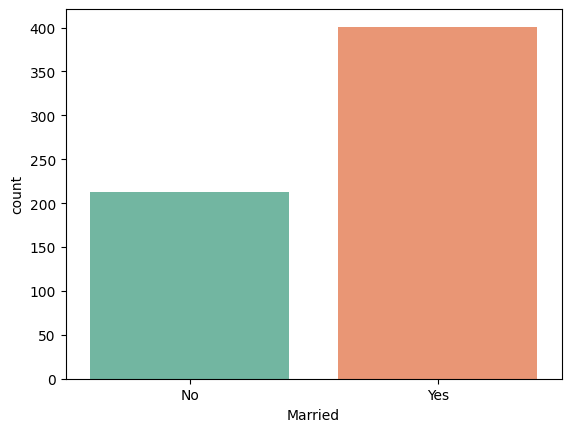

In [31]:
print("The number of peoples take loan as group by Martial status")
print(df['Married'].value_counts())
sns.countplot(x = 'Married' , data = df , palette = 'Set2')

In [32]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
loan_Amount_log      0
TotalIncome          0
TotalIncome_log      0
dtype: int64

The number of peoples take loan as group by loan Ammount status
LoanAmount
146.412162    22
120.000000    20
110.000000    17
100.000000    15
187.000000    12
              ..
292.000000     1
142.000000     1
350.000000     1
496.000000     1
253.000000     1
Name: count, Length: 204, dtype: int64


C:\Users\Dilan\AppData\Local\Temp\ipykernel_22776\983069527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'LoanAmount' , data = df , palette = 'Set2')


<Axes: xlabel='LoanAmount', ylabel='count'>

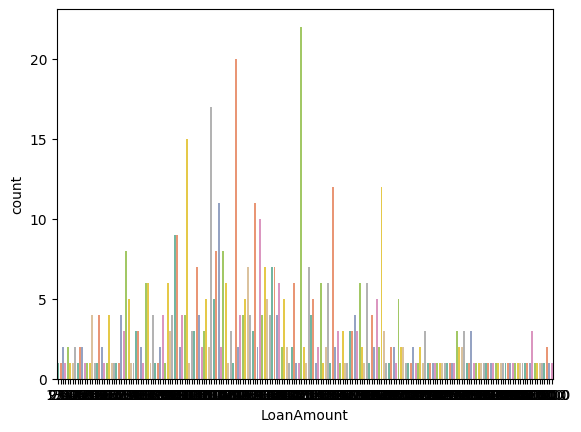

In [33]:
print("The number of peoples take loan as group by loan Ammount status")
print(df['LoanAmount'].value_counts())
sns.countplot(x = 'LoanAmount' , data = df , palette = 'Set2')

In [45]:
from sklearn.model_selection import train_test_split
ly = LabelEncoder()
y = ly.fit_transform(y)
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 0)

from sklearn.preprocessing import LabelEncoder
le_x = LabelEncoder()

In [46]:
for i in range(0 , 5):
    x_train[: , i] = le_x.fit_transform(x_train[: , i])
    x_train[: , 5] = le_x.fit_transform(x_train[: , 5])

x_train

array([[1, 1, 0, 0, 7, 81],
       [1, 0, 1, 0, 7, 131],
       [1, 1, 0, 0, 7, 98],
       ...,
       [1, 1, 3, 0, 7, 132],
       [1, 1, 0, 1, 7, 108],
       [0, 1, 0, 0, 7, 122]], shape=(491, 6), dtype=object)

In [48]:
for i in range(0 , 5):
    x_test[: , i] = le_x.fit_transform(x_test[: , i])
    x_test[: , 5] = le_x.fit_transform(x_test[: , 5])

x_test

array([[1, 0, 0, 0, 5, 10],
       [0, 0, 0, 0, 5, 24],
       [1, 1, 0, 0, 5, 71],
       [1, 1, 0, 0, 5, 22],
       [1, 1, 2, 0, 5, 16],
       [1, 1, 0, 1, 3, 48],
       [1, 1, 3, 0, 3, 45],
       [1, 0, 0, 0, 5, 72],
       [1, 0, 0, 0, 5, 30],
       [1, 1, 0, 0, 5, 33],
       [0, 0, 0, 0, 5, 10],
       [1, 1, 1, 0, 5, 14],
       [0, 0, 0, 0, 5, 68],
       [1, 1, 2, 0, 5, 65],
       [1, 1, 0, 0, 5, 15],
       [1, 1, 1, 0, 5, 3],
       [1, 0, 1, 1, 5, 58],
       [1, 0, 0, 1, 5, 36],
       [0, 0, 0, 0, 5, 13],
       [1, 1, 0, 1, 5, 55],
       [0, 1, 0, 0, 5, 28],
       [1, 1, 0, 0, 5, 43],
       [1, 1, 2, 0, 5, 21],
       [1, 1, 2, 0, 5, 48],
       [1, 1, 0, 0, 5, 2],
       [1, 1, 1, 0, 5, 66],
       [1, 0, 0, 0, 5, 57],
       [1, 1, 0, 0, 5, 57],
       [1, 1, 3, 0, 5, 33],
       [0, 0, 0, 0, 5, 18],
       [1, 1, 0, 0, 5, 64],
       [1, 0, 0, 1, 5, 1],
       [1, 1, 1, 1, 5, 12],
       [1, 1, 0, 0, 5, 54],
       [1, 1, 0, 0, 5, 34],
       [0, 1, 0, 1, 5, 

In [47]:
le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_train

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,

In [51]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()
x_train = s.fit_transform(x_train)
x_test = s.fit_transform(x_test)

x_train

array([[ 0.47374983,  0.71143163, -0.76304669, -0.53102197,  0.29835867,
        -0.02306033],
       [ 0.47374983, -1.40561644,  0.22549137, -0.53102197,  0.29835867,
         1.14422053],
       [ 0.47374983,  0.71143163, -0.76304669, -0.53102197,  0.29835867,
         0.37381516],
       ...,
       [ 0.47374983,  0.71143163,  2.2025675 , -0.53102197,  0.29835867,
         1.16756615],
       [ 0.47374983,  0.71143163, -0.76304669,  1.88316125,  0.29835867,
         0.60727133],
       [-2.11081869,  0.71143163, -0.76304669, -0.53102197,  0.29835867,
         0.93410998]], shape=(491, 6))

In [52]:
x_test

array([[ 0.46671381, -1.25      , -0.64059361, -0.51772699,  0.29935278,
        -1.17357808],
       [-2.14264068, -1.25      , -0.64059361, -0.51772699,  0.29935278,
        -0.47671551],
       [ 0.46671381,  0.8       , -0.64059361, -0.51772699,  0.29935278,
         1.86275168],
       [ 0.46671381,  0.8       , -0.64059361, -0.51772699,  0.29935278,
        -0.5762673 ],
       [ 0.46671381,  0.8       ,  1.37974009, -0.51772699,  0.29935278,
        -0.87492269],
       [ 0.46671381,  0.8       , -0.64059361,  1.93151993, -2.07615636,
         0.71790604],
       [ 0.46671381,  0.8       ,  2.38990694, -0.51772699, -2.07615636,
         0.56857834],
       [ 0.46671381, -1.25      , -0.64059361, -0.51772699,  0.29935278,
         1.91252758],
       [ 0.46671381, -1.25      , -0.64059361, -0.51772699,  0.29935278,
        -0.17806012],
       [ 0.46671381,  0.8       , -0.64059361, -0.51772699,  0.29935278,
        -0.02873243],
       [-2.14264068, -1.25      , -0.64059361, -0.

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
from sklearn import metrics 
y_pred = rf.predict(x_test )
print(f"Accuracy for Rnadom Forest is {metrics.accuracy_score(y_pred , y_test)}")

Accuracy for Rnadom Forest is 1.0


In [56]:
y_pred

array([0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [57]:
y_test

array([0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [59]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train , y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [62]:
y_pred = nb.predict(x_test)
print(f"Accuracy for Naive Baise is {metrics.accuracy_score(y_pred , y_test)}")
y_pred

Accuracy for Naive Baise is 1.0


array([0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [63]:
y_test

array([0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])